# Load answers

In [1]:
import pandas as pd

# load data file
df = pd.read_csv("C:\\Users\\Jessica Tran\\Downloads\\SUS Questionnaire.csv\\SUS Questionnaire.csv")
df = df.loc[:, ~df.columns.str.endswith(('[Resultat]', '[Feedback]'))]
df = df.drop(columns=["Tidsstempel","Point i alt", "Please write any additinal feedback below.", 'Age', 'Gender','Country of origin'])
df

,Comfort with Technology,I think that I would like to use this system frequently,I found the system unnecessarily complex,I thought the system was easy to use,I think that I would need the support of a technical person to be able to use this system.,I found the various functions in this system were well integrated,I thought there was too much inconsistency in this system,I would imagine that most people would learn to use this system very quickly,I found the system very cumbersome to use,I felt very confident using the system,I needed to learn a lot of things before I could get going with this system
0,Somewhat comfortable,2,1,4,2,3,4,4,1,3,1
1,Not comfortable,1,4,2,4,3,4,3,4,2,4
2,Very comfortable,2,1,5,1,5,1,5,1,5,1
3,Very comfortable,2,1,4,2,5,1,4,1,4,1
4,Not comfortable,3,2,5,1,4,2,4,1,3,1
5,Not comfortable,1,2,5,1,4,2,4,1,4,2
6,Somewhat comfortable,4,2,4,2,5,3,5,1,4,1
7,Somewhat comfortable,3,2,5,1,4,1,3,2,3,2
8,Very comfortable,1,1,5,1,4,2,5,1,3,1
9,Not comfortable,2,2,5,1,4,2,3,1,5,2


In [2]:
df.dtypes

Comfort with Technology                                                                       object
I think that I would like to use this system frequently                                        int64
I found the system unnecessarily complex                                                       int64
I thought the system was easy to use                                                           int64
I think that I would need the support of a technical person to be able to use this system.     int64
I found the various functions in this system were well integrated                              int64
I thought there was too much inconsistency in this system                                      int64
I would imagine that most people would learn to use this system very quickly                   int64
I found the system very cumbersome to use                                                      int64
I felt very confident using the system                                                     

In [3]:
df['Comfort with Technology'] = df['Comfort with Technology'].astype('category')

# Compute SUS score for each row

In [4]:
import pandas as pd

# Define a function to compute the SUS score
def compute_sus(row):
    sus_score = 0
    for i in range(1, 11):
        if i % 2 != 0:  # Odd-numbered questions (1st, 3rd, 5th, 7th, 9th)
            sus_score += (row[i] - 1)
        else:  # Even-numbered questions (2nd, 4th, 6th, 8th, 10th)
            sus_score += (5 - row[i])
    
    # Multiply by 2.5 to get the final SUS score
    return sus_score * 2.5

# Apply the function to each row in the dataframe to compute the SUS score
df['SUS_score'] = df.apply(compute_sus, axis=1)

df

,Comfort with Technology,I think that I would like to use this system frequently,I found the system unnecessarily complex,I thought the system was easy to use,I think that I would need the support of a technical person to be able to use this system.,I found the various functions in this system were well integrated,I thought there was too much inconsistency in this system,I would imagine that most people would learn to use this system very quickly,I found the system very cumbersome to use,I felt very confident using the system,I needed to learn a lot of things before I could get going with this system,SUS_score
0,Somewhat comfortable,2,1,4,2,3,4,4,1,3,1,67.5
1,Not comfortable,1,4,2,4,3,4,3,4,2,4,27.5
2,Very comfortable,2,1,5,1,5,1,5,1,5,1,92.5
3,Very comfortable,2,1,4,2,5,1,4,1,4,1,82.5
4,Not comfortable,3,2,5,1,4,2,4,1,3,1,80.0
5,Not comfortable,1,2,5,1,4,2,4,1,4,2,75.0
6,Somewhat comfortable,4,2,4,2,5,3,5,1,4,1,82.5
7,Somewhat comfortable,3,2,5,1,4,1,3,2,3,2,75.0
8,Very comfortable,1,1,5,1,4,2,5,1,3,1,80.0
9,Not comfortable,2,2,5,1,4,2,3,1,5,2,77.5


## Visualize SUS score grouped by 'Comfortability in Technology'

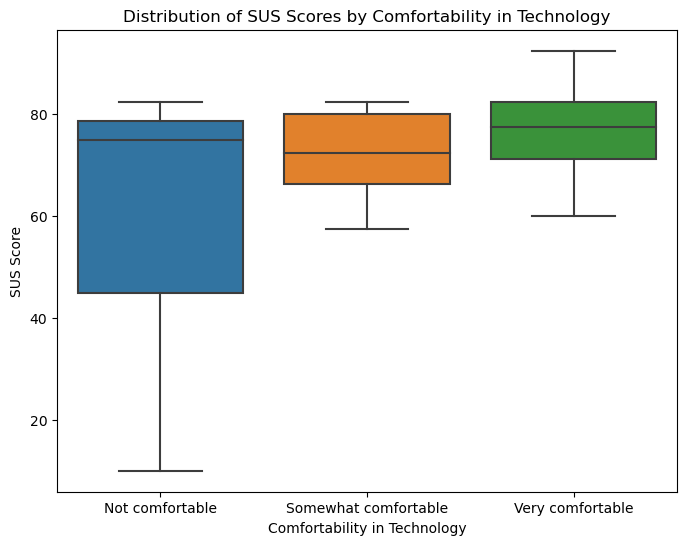

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=df.iloc[:, 0], y=df['SUS_score'])

# Labels and title
plt.xlabel('Comfortability in Technology')
plt.ylabel('SUS Score')
plt.title('Distribution of SUS Scores by Comfortability in Technology')
plt.show()

# One-way ANOVA

## Check for normality

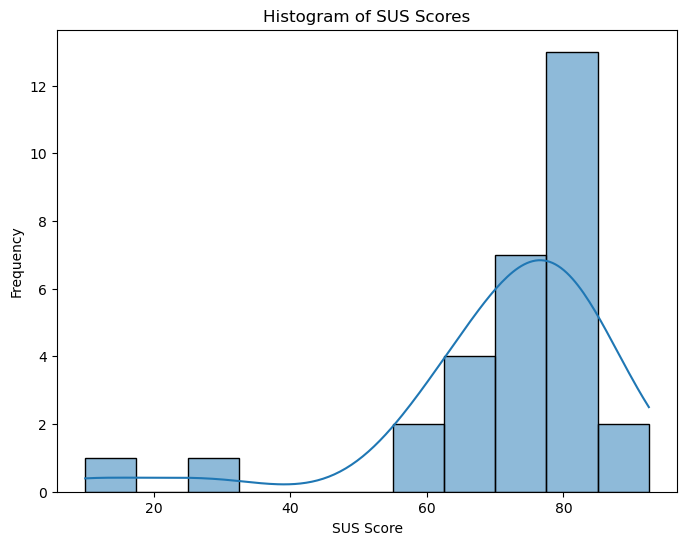

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram
plt.figure(figsize=(8, 6))
sns.histplot(df['SUS_score'], kde=True)
plt.title('Histogram of SUS Scores')
plt.xlabel('SUS Score')
plt.ylabel('Frequency')
plt.show()

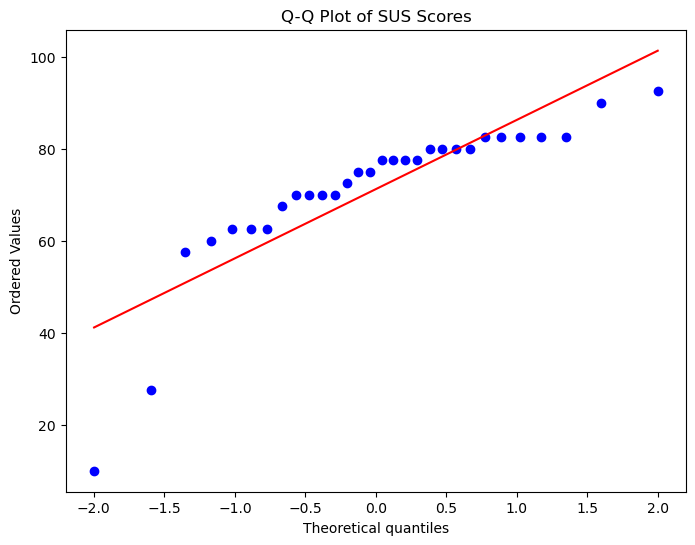

In [7]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Q-Q plot to visually assess normality
plt.figure(figsize=(8, 6))
stats.probplot(df['SUS_score'], dist="norm", plot=plt)
plt.title('Q-Q Plot of SUS Scores')
plt.show()

In [8]:
from scipy.stats import shapiro

# Perform the Shapiro-Wilk Test for normality
stat, p_value = shapiro(df['SUS_score'])

print(f"Shapiro-Wilk Test: Statistic={stat}, p-value={p_value}")

# Interpretation
if p_value > 0.05:
    print("The SUS scores appear to follow a normal distribution (fail to reject H0).")
else:
    print("The SUS scores do not follow a normal distribution (reject H0).")

Shapiro-Wilk Test: Statistic=0.7653908973661812, p-value=1.6309968493276258e-05
The SUS scores do not follow a normal distribution (reject H0).


In [9]:
from scipy.stats import kstest

# Perform the Kolmogorov-Smirnov Test for normality
stat, p_value = kstest(df['SUS_score'], 'norm')

print(f"Kolmogorov-Smirnov Test: Statistic={stat}, p-value={p_value}")

# Interpretation
if p_value > 0.05:
    print("The SUS scores appear to follow a normal distribution (fail to reject H0).")
else:
    print("The SUS scores do not follow a normal distribution (reject H0).")


Kolmogorov-Smirnov Test: Statistic=1.0, p-value=0.0
The SUS scores do not follow a normal distribution (reject H0).


In [10]:
from scipy.stats import skew, kurtosis

# Calculate skewness and kurtosis
skewness = skew(df['SUS_score'])
kurt = kurtosis(df['SUS_score'])

print(f"Skewness: {skewness}")
print(f"Kurtosis: {kurt}")

# Interpretation
if abs(skewness) < 1 and abs(kurt) < 1:
    print("The SUS scores appear to be approximately normally distributed (based on skewness and kurtosis).")
else:
    print("The SUS scores do not appear to be normally distributed (based on skewness and kurtosis).")

Skewness: -2.1740561193286165
Kurtosis: 5.221485389935429
The SUS scores do not appear to be normally distributed (based on skewness and kurtosis).


Based on the two plots and four statistical tests the SUS score is not normally distributed - failing to full the assumption of normality. Instead of ANOVA the Kruskal-Wallis H Test is used to test for significance.

# Mann-Whitney-Wilcoxon Test

In [12]:
from scipy.stats import kruskal

# Group the data by 'Comfort with Technology'
groups = [df[df['Comfort with Technology'] == level]['SUS_score'] for level in df['Comfort with Technology'].unique()]

# Perform the Kruskal-Wallis H test
stat, p_value = kruskal(*groups)

# Print the results
print(f"Kruskal-Wallis H-test: Statistic = {stat}, p-value = {p_value}")

# Interpretation of results
if p_value < 0.05:
    print("The difference in SUS scores across comfortability levels is statistically significant (reject H0).")
else:
    print("No significant difference in SUS scores across comfortability levels (fail to reject H0).")

Kruskal-Wallis H-test: Statistic = 2.44614338364337, p-value = 0.2943247022009947
No significant difference in SUS scores across comfortability levels (fail to reject H0).
